# Exercise 5: Introduction to Inverse Problems

Inverse problems arise in many areas of science and engineering where we aim to recover unknown model parameters from observed data. In contrast to forward problems where data are predicted from known model parameters, inverse problems attempt to reconstruct the model that explains the measurements.

In this exercise, we explore fundamental concepts of inverse problems using linear algebra and signal processing tools. We begin by studying linear systems of the form  

\[
A x = b
\]

and investigate how the properties of the matrix \(A\) determine whether the system has:

- A **unique solution** (well-determined system),
- **No solution** (inconsistent system),
- **Infinitely many solutions** (underdetermined system),
- Or requires a **least-squares solution** (overdetermined system).

We will examine orthogonality, invertibility, adjoints, and the role of the null space, all of which are central concepts in inverse theory.

The second part of the exercise introduces **convolution and deconvolution**, demonstrating how linear operators act in both the time and frequency domains. Using the Fourier transform, we explore:

- Convolution as multiplication in the frequency domain,
- The concept of an operator null space,
- The use of adjoints as approximate inverses,
- Iterative least-squares methods (e.g., LSQR) for inversion.

Let's start with some basic julia matrix operations

In [3]:
A = [1 2;3 -1]

2×2 Matrix{Int64}:
 1   2
 3  -1

In [4]:
A'

2×2 adjoint(::Matrix{Int64}) with eltype Int64:
 1   3
 2  -1

In [5]:
x = [2; 2]

2-element Vector{Int64}:
 2
 2

* Describe two ways to define a row vector.

# Tasks

In [6]:
A1 = [1/sqrt(2) 2/3 sqrt(2)/6;0 1/3 -2*sqrt(2)/3;-1/sqrt(2) 2/3 sqrt(2)/6];
A2 = [0 2 2;2 1 -3;1 0 -2];
A3 = [3 1;1 0;2 1];
A4 = [2 4 3; 1 3 1];

* Look at A1'*A1, what kind of matrix is A1? What does this mean?

In [ ]:
A1'*A1

* Look at A2[1;2;3] and A2[3;1;4], what can you say about the matrix A2?

In [ ]:
A2*[1;2;3] 

In [ ]:
A2*[3;1;4]

* What do you call a linear system defined by matrix A3?

In [ ]:
A3

* What do you call a linear system defined by matrix A4?

In [ ]:
A4

* Find a solution of A1*x = [6;-3;0], is there only one solution? Do you really need inv here?

* Find a solution of A2*x = [4;0;-1], is there only one solution? What characterizes the solution you found?

* Find a solution of A3*x = [5;2;5], is there only one solution? What characterizes the solution you found?

* Find a solution of A4*x = [10;5], is there only one solution? What characterizes the solution you found?

# JOLI (Julia Operator LIbrary) is a package for creating algebraic linear operators)

In [7]:
using Pkg
#Pkg.add("FFTW")

In [8]:
using FFTW
# dimension
N  = 10
F1 = zeros(Complex{Float64}, N,N)
for k = 1:N
    # construct k-th unit vector
    ek = zeros(N,1)
    ek[k] = 1

    # make column of matrix
    F1[:, k]= fft(ek)
end

* Look at the matrix, what do you notice?

In [ ]:
F1

* Verify that it gives the same result as fft by trying on a vector

In [19]:
using Random
vec = rand(Float64,10);

In [11]:
using JOLI

In [12]:
F2  = joDFT(N)

joLinearFunction{Float64, ComplexF64}("joDFT_p", 10, 10, JOLI.var"#855#871"{DataType, Tuple{Int64}, FFTW.cFFTWPlan{ComplexF64, -1, false, 1, UnitRange{Int64}}}(ComplexF64, (10,), FFTW forward plan for 10-element array of ComplexF64
(dft-direct-10 "n2fv_10_avx2_128")), Nullable{Function}(JOLI.var"#122#126"{JOLI.var"#856#872"{DataType, Tuple{Int64}, AbstractFFTs.ScaledPlan{ComplexF64, FFTW.cFFTWPlan{ComplexF64, 1, false, 1, UnitRange{Int64}}, Float64}}}(JOLI.var"#856#872"{DataType, Tuple{Int64}, AbstractFFTs.ScaledPlan{ComplexF64, FFTW.cFFTWPlan{ComplexF64, 1, false, 1, UnitRange{Int64}}, Float64}}(Float64, (10,), 0.1 * FFTW backward plan for 10-element array of ComplexF64
(dft-direct-10 "n2bv_10_avx2_128")))), Nullable{Function}(JOLI.var"#856#872"{DataType, Tuple{Int64}, AbstractFFTs.ScaledPlan{ComplexF64, FFTW.cFFTWPlan{ComplexF64, 1, false, 1, UnitRange{Int64}}, Float64}}(Float64, (10,), 0.1 * FFTW backward plan for 10-element array of ComplexF64
(dft-direct-10 "n2bv_10_avx2_128"))), 

In [13]:
varinfo(r"F1"), varinfo(r"F2")

(| name |      size | summary                  |
|:---- | ---------:|:------------------------ |
| F1   | 1.602 KiB | 10×10 Matrix{ComplexF64} |
, | name |      size | summary                               |
|:---- | ---------:|:------------------------------------- |
| F2   | 711 bytes | joLinearFunction{Float64, ComplexF64} |
)

In [20]:
N  = 10000;
# NxN Gaussian matrix
G1 = ones(N, N);

In [21]:
# NxN Gaussian JOLI operator (will represent a different matrix than G1 becuase it is gerenated randomly)
G2 = joOnes(N);

In [16]:
varinfo(r"G1"),varinfo(r"G2")


(| name |        size | summary                     |
|:---- | -----------:|:--------------------------- |
| G1   | 762.939 MiB | 10000×10000 Matrix{Float64} |
, | name |      size | summary                    |
|:---- | ---------:|:-------------------------- |
| G2   | 246 bytes | joMatrix{Float64, Float64} |
)

# Deconvolution

Note: Plotting of signals is compulsory for the tasks below.

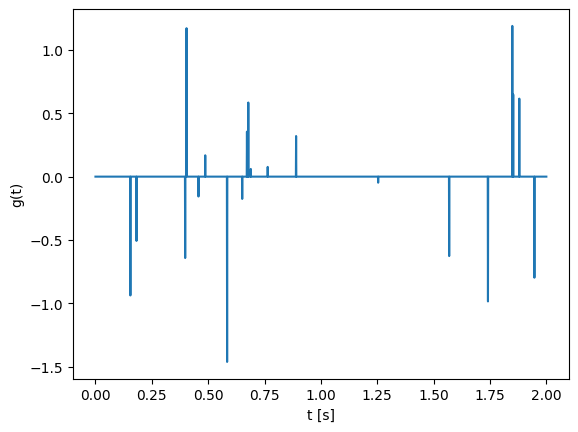

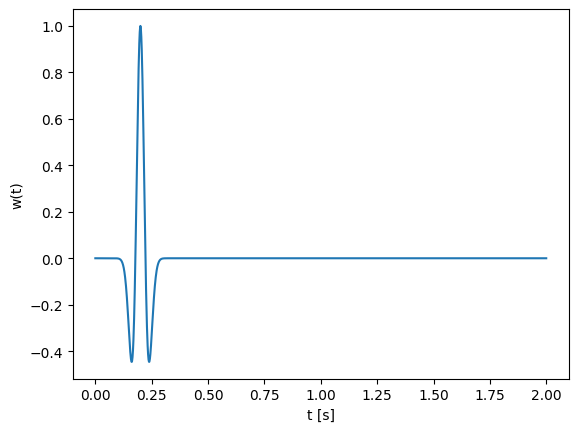

In [22]:
# time axis
t = 0:.001:2';
N = length(t);

# true signal g has approx k spikes with random amplitudes
k = 20;
g = zeros(N);
g[rand(1:N, k)] = randn(k);

# filter
w = (1 .-2*1e3*(t .-.2).^2).*exp.(-1e3*(t .-.2).^2);

# plot
using PyPlot
figure();
plot(t,g);
xlabel("t [s]");ylabel("g(t)");

figure();
plot(t,w);
xlabel("t [s]");ylabel("w(t)");

# Task: Perform the convolution using the usual julia commands fft, ifft and element-wise multiplication. Name your result f1. Plot it

In [ ]:
f1 = 
plot(t,f1)
xlabel("t [s]")
ylabel("f1")

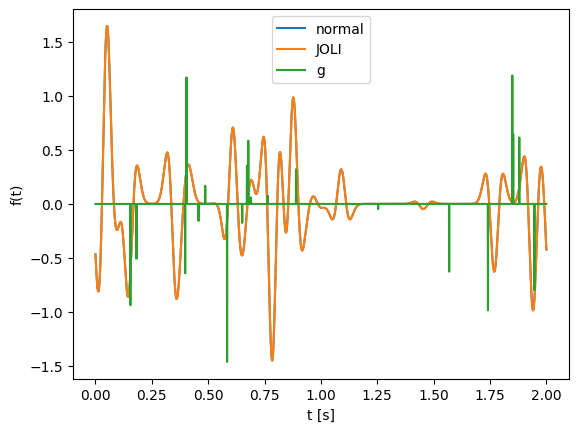

In [24]:
# JOLI operator to perform convolution.
wf = fft(w);

C = joDFT(N)'*joDiag(wf)*joDFT(N);
f2 = C*g;

figure();
plot(t,f1)
plot(t,f2)
plot(t,g);
xlabel("t [s]");ylabel("f(t)");legend(["normal","JOLI", "g"]);

# Task

* Compare the results of both.  

* Compare f2 to g, what do you notice?

 * Assuming that your convolution operator is called C: Do you think C has a null-space? If so, describe it. (Hint: look at the filter).

In [35]:
#filter
w

In [25]:
f = C*g + 1e-3*randn(N);

# Task

* Use the adjoint of C as an approximation to the inverse, i.e. approximate the adjoint of C to the observation f. what does this correspond to and what does the reconstruction look like?

In [ ]:
g_recons = 

# Matrix-Free Damped LSQR vs Normal Equations

In this section we compare two equivalent ways of solving the damped least-squares problem:

$$
\min_x \|Ax - b\|_2^2 + \lambda \|x\|_2^2
$$

### 1) Normal Equations (Explicit Matrix Form)

The classical formula is:

$$
x = (A^T A + \lambda I)^{-1} A^T b
$$

This requires forming `A' * A`, which:
- Squares the condition number (less stable)
- Requires storing a dense matrix
- Scales poorly for large problems

### 2) Matrix-Free Damped LSQR

Instead, we can use:

```julia
x_lsqr = lsqr(A, b; damp = sqrt(λ))
```

LSQR never forms `A' * A` explicitly.
It only requires the ability to compute:

- `A * x`
- `A' * y`

In our case, the operator `C` is built using FFT-based operators (`joDFT`),
which are *matrix-free*. This means:

- The full matrix is never stored.
- Multiplications use FFTs internally.
- Memory scales like O(N), not O(N²).
- Computational cost scales like O(N log N).

This is why matrix-free methods are essential in large-scale inverse problems,
such as seismic imaging and deconvolution.

We now verify that damped LSQR gives the same solution as the normal equations
(for small problem sizes where forming matrices is feasible).


In [30]:
# Compare Normal Equations and LSQR
using LinearAlgebra
λ = 1.0

# Normal equations (explicit matrix form)
#Cmat = Matrix(C)          
n = size(C, 2)
Id = Matrix{Float64}(I, n, n)
Cmat = C * Id  # Only safe for small N!
x_ne = (Cmat' * Cmat + λ * I) \ (Cmat' * f)

2001-element Vector{Float64}:
 -0.0014099840169985787
 -0.0006144573797535009
  0.00018423298420531682
  0.0009651535881563676
  0.0017087091293378582
  0.0023970806812042907
  0.0030146030182000056
  0.0035480742537285287
  0.003986992840203667
  0.004323718898531086
  0.004553558765226495
  0.00467477352277139
  0.004688514069601323
  ⋮
 -0.003597153413312668
 -0.004227742590190715
 -0.004694354383757469
 -0.004993037937305006
 -0.005124255159082125
 -0.005092662643599067
 -0.004906803481949298
 -0.0045787196287387635
 -0.004123497000875563
 -0.003558756647616925
 -0.002904106135222062
 -0.002180565727560447

# Task

* Follow the script below, use lsqr to invert for g. (you might need to increase the number of iterations). Do you notice the relative difference between the normal equations lsqr? Now look at the signal that is predicted by your reconstruction, do you see a difference with the true signal?

In [32]:
# Damped LSQR (matrix-free)

#import Pkg;
#Pkg.add("IterativeSolvers")
# true signal
using IterativeSolvers
x_lsqr = lsqr(C, f; damp = sqrt(λ))

println("Relative difference between solutions: ",
        norm(x_ne - x_lsqr) / norm(x_ne))

Relative difference between solutions: 5.666950223694139e-7


In [ ]:
plot(t,x_lsqr)
xlabel("t [s]")
ylabel("x_lsqr")

Check with a larger problem size (larger N) and observe the scalability advantage in case of matrix-free opeartors.

Let's use another method

In [ ]:
#Pkg.add(url="https://github.com/slimgroup/GenSPGL.jl")
using GenSPGL
# Solve
opts = spgOptions(optTol = 1e-10,
                  verbosity = 1)

gtt, r, grads, info = spgl1(C, f, tau = 0., sigma = norm(f - C*gt));

  114  1.3479129e+00  2.1893027e-01   7.85e-01  9.695e-01     0.0
  115  1.3475799e+00  1.9146569e-01   7.85e-01  9.479e-01     0.0
  116  1.3454067e+00  3.2431449e-01   7.85e-01  9.989e-01     0.0
  117  1.3452839e+00  6.1790661e-01   7.85e-01  1.112e+00    -0.9  1.5786757e+01
  118  9.3178320e-01  2.5145209e+00   6.42e-01  1.280e+00     0.0
  119  9.0250463e-01  2.8242951e+00   6.13e-01  1.632e+00     0.0
  120  7.9743335e-01  2.2658312e+00   5.08e-01  1.077e+00     0.0
  121  7.7565424e-01  1.3203719e+00   4.86e-01  6.517e-01     0.0
  122  7.6414035e-01  1.1726593e+00   4.75e-01  6.793e-01     0.0
  123  7.4194750e-01  1.8369000e+00   4.53e-01  8.024e-01     0.0
  124  7.6874128e-01  2.6579101e+00   4.79e-01  1.657e+00    -0.3
  125  7.3971419e-01  2.2759333e+00   4.50e-01  9.634e-01     0.0
  126  7.2542638e-01  8.9256315e-01   4.36e-01  6.616e-01     0.0
  127  7.2310410e-01  7.0982320e-01   4.34e-01  5.908e-01     0.0
  128  7.1577382e-01  6.9902219e-01   4.26e-01  5.927e-01    

  238  2.7735913e-01  1.5781002e+00   1.20e-02  5.255e-01     0.0
  239  2.8937029e-01  2.8500757e+00   1.18e-05  1.331e+00    -0.6
-----------------------------------------------------------------------

Exit Condition Number:          2

Exit Condition Triggered:       EXIT_BPSOL_FOUND

Additional Information:         EXIT -- Found a BP solution




In [ ]:
plot(t,gtt)
xlabel("t [s]")
ylabel("gtt")

# Task

* Is this solution closer to the true one?

* Look at the predicted signal for this solution, do you see a difference with the true signal? Can we really say that this is a better solution?